## HIPOTESIS 1

In [ ]:
import pandas as pd
from scipy.stats import shapiro, levene, ttest_ind
from scipy import stats

# Cargar el archivo Excel
df = pd.read_excel("/tstudent_algoritmos.xlsx")

# Seleccionar columnas
grupo_A = df["Algoritmo_A_ops_sec"].dropna()
grupo_B = df["Algoritmo_B_ops_sec"].dropna()

# Prueba de normalidad Shapiro-Wilk
stat_A, p_A = shapiro(grupo_A)
stat_B, p_B = shapiro(grupo_B)
print(f"Shapiro-Wilk Grupo A: p = {p_A:.4f} → {'Normal' if p_A > 0.05 else 'No normal'}")
print(f"Shapiro-Wilk Grupo B: p = {p_B:.4f} → {'Normal' if p_B > 0.05 else 'No normal'}")

# Prueba de homocedasticidad Levene
stat_lev, p_lev = levene(grupo_A, grupo_B)
print(f"Levene: p = {p_lev:.4f} → {'Varianzas iguales' if p_lev > 0.05 else 'Varianzas distintas'}")


Shapiro-Wilk Grupo A: p = 0.4280 → Normal
Shapiro-Wilk Grupo B: p = 0.1760 → Normal
Levene: p = 0.0706 → Varianzas iguales


In [ ]:
# Si p_lev > 0.05 → t-Student (equal_var=True), si no → Welch (equal_var=False)
equal_var = p_lev > 0.05

# Prueba t de muestras independientes
t_stat, p_valor = ttest_ind(grupo_A, grupo_B, equal_var=equal_var)
print(f"\nt-test: p = {p_valor:.4f} → {'No rechazar H0' if p_valor > 0.05 else 'Rechazar H0'}")



t-test: p = 0.0000 → Rechazar H0


In [ ]:
import numpy as np
import math

# Calcular medias y desviaciones estándar
mean_diff = np.mean(grupo_A) - np.mean(grupo_B)
if equal_var:

    pooled_std = math.sqrt(
        ((grupo_A.std(ddof=1) ** 2) / len(grupo_A)) +
        ((grupo_B.std(ddof=1) ** 2) / len(grupo_B))
    )
    df_deg = len(grupo_A) + len(grupo_B) - 2
else:
    # Welch standard error
    pooled_std = math.sqrt(
        (grupo_A.var(ddof=1) / len(grupo_A)) +
        (grupo_B.var(ddof=1) / len(grupo_B))
    )
    df_deg = ((grupo_A.var(ddof=1) / len(grupo_A)) + (grupo_B.var(ddof=1) / len(grupo_B))) ** 2 / (
        ((grupo_A.var(ddof=1) / len(grupo_A)) ** 2) / (len(grupo_A) - 1) +
        ((grupo_B.var(ddof=1) / len(grupo_B)) ** 2) / (len(grupo_B) - 1)
    )

# Intervalo de confianza
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df_deg)
ci_lower = mean_diff - t_crit * pooled_std
ci_upper = mean_diff + t_crit * pooled_std
print(f"IC 95% para la diferencia de medias: [{ci_lower:.4f}, {ci_upper:.4f}]")


IC 95% para la diferencia de medias: [57.5929, 71.1698]


<ipython-input-13-0d0500b281fd>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_largo, x='Algoritmo', y='Operaciones por segundo', palette='pastel')


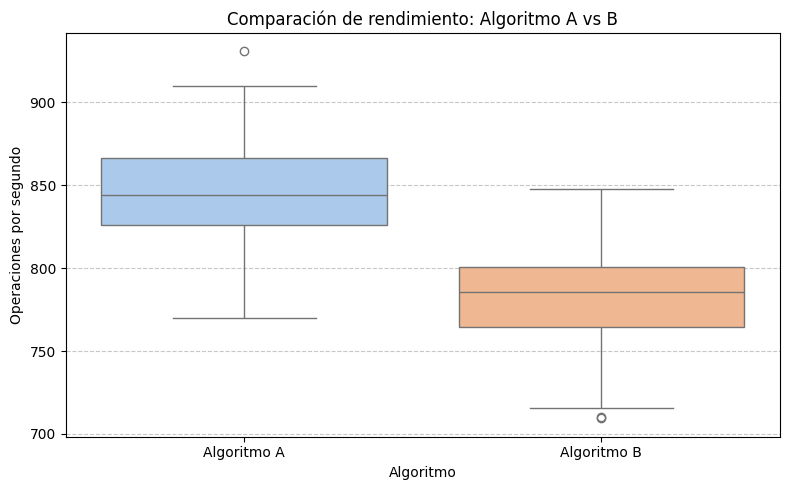

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df = pd.read_excel("/tstudent_algoritmos.xlsx")

# Renombrar columnas para facilidad
df = df.rename(columns={
    "Algoritmo_A_ops_sec": "Algoritmo A",
    "Algoritmo_B_ops_sec": "Algoritmo B"
})

# Crear un DataFrame largo para seaborn
df_largo = pd.melt(df, var_name='Algoritmo', value_name='Operaciones por segundo')

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_largo, x='Algoritmo', y='Operaciones por segundo', palette='pastel')
plt.title("Comparación de rendimiento: Algoritmo A vs B")
plt.ylabel("Operaciones por segundo")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


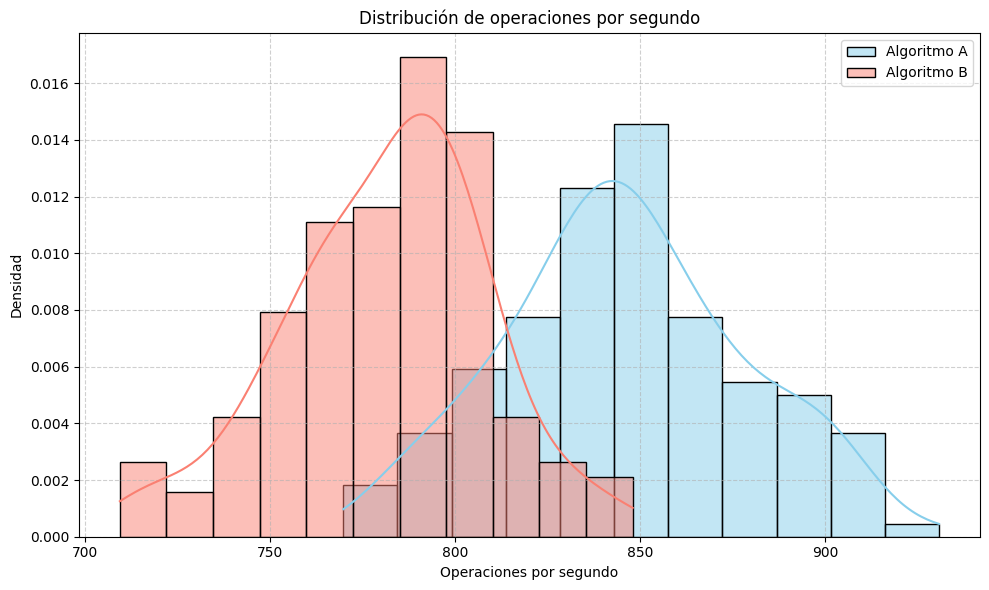

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Algoritmo A"], kde=True, color="skyblue", label="Algoritmo A", stat="density")
sns.histplot(df["Algoritmo B"], kde=True, color="salmon", label="Algoritmo B", stat="density")
plt.title("Distribución de operaciones por segundo")
plt.xlabel("Operaciones por segundo")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


<ipython-input-15-ee6ec840daca>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_largo, x='Algoritmo', y='Operaciones por segundo', palette="Set2")


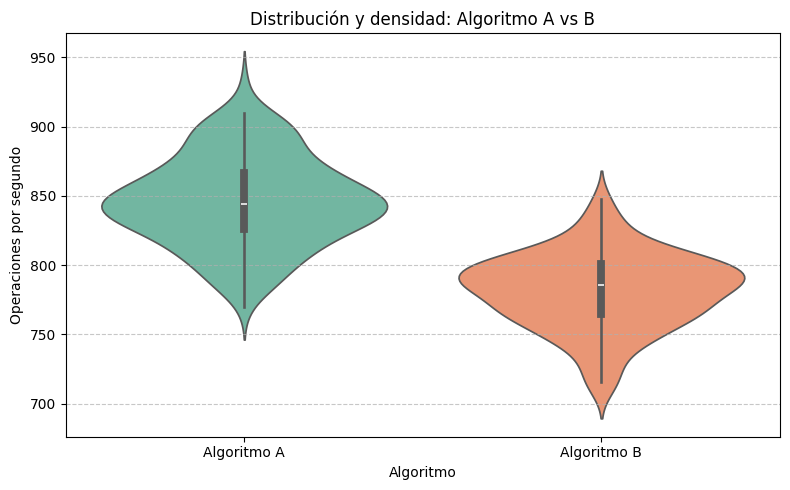

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_largo, x='Algoritmo', y='Operaciones por segundo', palette="Set2")
plt.title("Distribución y densidad: Algoritmo A vs B")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**HIPOTESIS 2**

Shapiro-Wilk Red X: p = 0.9428 → Normal
Shapiro-Wilk Red Y: p = 0.1133 → Normal


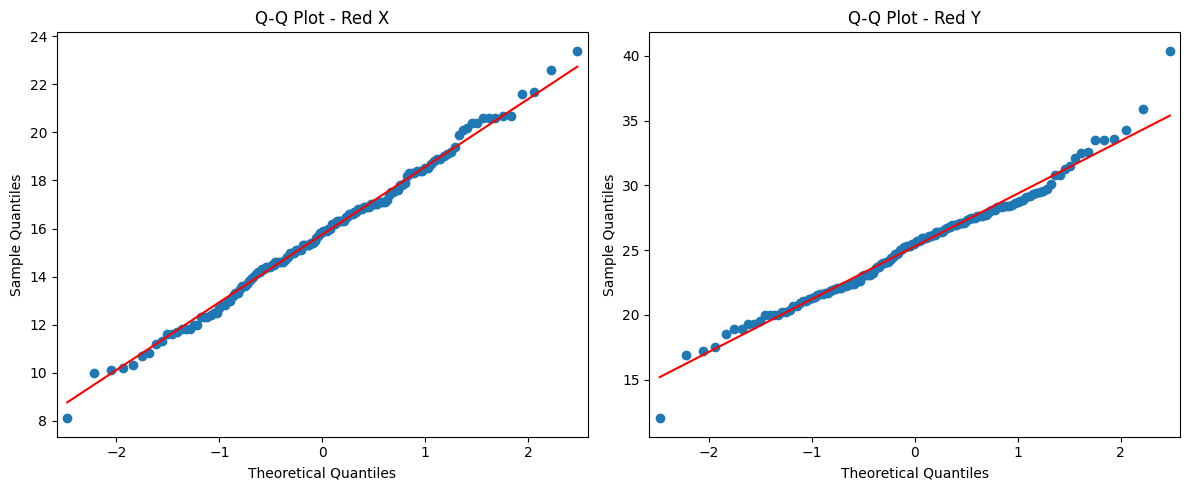


Mann-Whitney U = 536.5
p-valor (cola inferior): 0.0000 → Rechazar H₀


In [ ]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


df = pd.read_excel("/mannwhitney_redes.xlsx")


red_x = df["Red_X_ms"]
red_y = df["Red_Y_ms"]


# 1. Verificación de no normalidad

# Shapiro-Wilk
sw_x = stats.shapiro(red_x)
sw_y = stats.shapiro(red_y)

print(f"Shapiro-Wilk Red X: p = {sw_x.pvalue:.4f} → {'Normal' if sw_x.pvalue > 0.05 else 'No normal'}")
print(f"Shapiro-Wilk Red Y: p = {sw_y.pvalue:.4f} → {'Normal' if sw_y.pvalue > 0.05 else 'No normal'}")

# Gráfico Q-Q para Red X y Red Y
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sm.qqplot(red_x, line='s', ax=plt.gca())
plt.title("Q-Q Plot - Red X")

plt.subplot(1, 2, 2)
sm.qqplot(red_y, line='s', ax=plt.gca())
plt.title("Q-Q Plot - Red Y")

plt.tight_layout()
plt.show()


# 2. Mann-Whitney U Test (cola inferior)

u_stat, p_valor = stats.mannwhitneyu(red_x, red_y, alternative='less')  # Cola inferior


# 3. Reporte de resultados

print(f"\nMann-Whitney U = {u_stat}")
print(f"p-valor (cola inferior): {p_valor:.4f} → {'Rechazar H₀' if p_valor < 0.05 else 'No rechazar H₀'}")


**HIPOTESIS 3**

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel("/anova_cifrado.xlsx")

# Ver las primeras filas para entender la estructura
print(df.head())

# 1. Verificación de normalidad (Test de Shapiro-Wilk)
normality_results = {}
for col in df.columns:
    stat, p_value = stats.shapiro(df[col])
    normality_results[col] = p_value
    print(f"Normalidad para {col}: p-value = {p_value}")

# 2. Verificación de homocedasticidad (Test de Levene)
stat, p_value = stats.levene(df['AES_256'], df['RSA_2048'], df['ChaCha20'])
print(f"Homocedasticidad (Levene test): p-value = {p_value}")

# 3. ANOVA (solo si la homocedasticidad se cumple)
if p_value > 0.05:
    model = ols('AES_256 + RSA_2048 + ChaCha20 ~ 1', data=df).fit()
    anova_results = anova_lm(model)
    print("Resultados ANOVA:")
    print(anova_results)
else:
    print("No se cumple la homocedasticidad, se usará Kruskal-Wallis.")

# 4. Usar Kruskal-Wallis si no se cumple homocedasticidad
if p_value < 0.05:
    stat, p_value_kw = stats.kruskal(df['AES_256'], df['RSA_2048'], df['ChaCha20'])
    print(f"Resultados Kruskal-Wallis: p-value = {p_value_kw}")

    # Si el p-value es significativo, se puede proceder con un análisis post-hoc
    if p_value_kw < 0.05:
        print("Kruskal-Wallis es significativo, aplicamos pruebas post-hoc.")



   AES_256  RSA_2048  ChaCha20
0     13.0      25.8       8.8
1     11.7      26.0       9.2
2     13.3      23.0      11.1
3     15.0      25.7      10.9
4     11.5      25.9      10.0
Normalidad para AES_256: p-value = 0.9413085788911156
Normalidad para RSA_2048: p-value = 0.1116953655235905
Normalidad para ChaCha20: p-value = 0.6243223497077693
Homocedasticidad (Levene test): p-value = 2.7368940425452205e-14
No se cumple la homocedasticidad, se usará Kruskal-Wallis.
Resultados Kruskal-Wallis: p-value = 4.799742280672654e-72
Kruskal-Wallis es significativo, aplicamos pruebas post-hoc.


**HIPOTESIS 4**

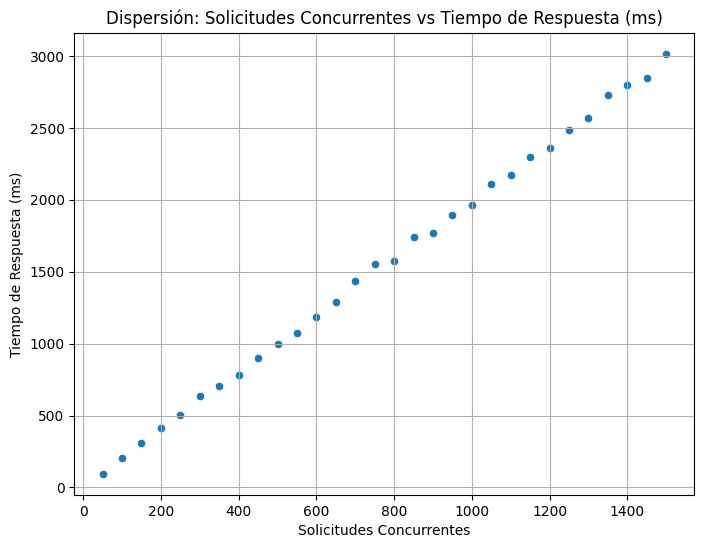

Coeficiente de correlación de Pearson: 0.9995960891352763
Valor p: 7.513415157191777e-45
La correlación es significativa.
Rechazar H₀: Existe una correlación positiva significativa entre las solicitudes concurrentes y el tiempo de respuesta.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel("/correlacion_servidor.xlsx")

# 1. Graficar dispersión (scatter plot)
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Solicitudes_Concurrentes'], y=df['Tiempo_Respuesta_ms'])
plt.title('Dispersión: Solicitudes Concurrentes vs Tiempo de Respuesta (ms)')
plt.xlabel('Solicitudes Concurrentes')
plt.ylabel('Tiempo de Respuesta (ms)')
plt.grid(True)
plt.show()

# 2. Calcular Pearson y su valor p
correlation_coefficient, p_value = stats.pearsonr(df['Solicitudes_Concurrentes'], df['Tiempo_Respuesta_ms'])

# 3. Discutir fuerza (coeficiente r) y significancia
print(f"Coeficiente de correlación de Pearson: {correlation_coefficient}")
print(f"Valor p: {p_value}")

# Interpretar el coeficiente de correlación de Pearson
if p_value < 0.05:
    significance = "significativa"
else:
    significance = "no significativa"

print(f"La correlación es {significance}.")

if p_value < 0.05:
    print("Rechazar H₀: Existe una correlación positiva significativa entre las solicitudes concurrentes y el tiempo de respuesta.")
else:
    print("No rechazar H₀: No existe correlación significativa entre las solicitudes concurrentes y el tiempo de respuesta.")
